# Day 1 — Time Series Forecasting Pipeline
### Data Cleaning → Model Training → Evaluation → Hyperparameter Tuning → MLflow

---

This notebook is your **end-to-end pipeline**  
It builds on the work done in the previous weeks  

### What we will do today

| Step | What happens |
|---|---|
| **1** | Install and import everything we need |
| **2** | Load the feature-engineered dataset |
| **3** | Clean the data — fill gaps and missing values |
| **4** | Train all five models on the same data |
| **5** | Evaluate every model with consistent metrics |
| **6** | Tune the best model with hyperparameter search |
| **7** | Track everything in MLflow |


> **Dataset:** `timeseries_with_features.csv` — built in the Feature Engineering notebook (Week 1).

---

---
## Step 1 — Install and Import Libraries

Run this cell once. It installs everything we need for today.

In [1]:
# Install all required packages for today
# The ! runs a terminal command from inside the notebook

! pip install pandas numpy matplotlib scikit-learn xgboost statsmodels prophet mlflow -q

print("All packages installed!")

All packages installed!


In [2]:
# ── Core libraries ──────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Time series models ───────────────────────────────────────
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
import xgboost as xgb

# ── Evaluation ───────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# ── MLflow ───────────────────────────────────────────────────
import mlflow
import mlflow.xgboost

warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

c:\Users\alipa\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


All libraries imported successfully!


---
## Step 2 — Load the Dataset

We load the feature-engineered CSV that was built in the Week 1 Feature Engineering notebook.  
Change `DATA_DIR` to the folder where your file is saved.

In [3]:
# ── Change this to YOUR folder path ─────────────────────────
DATA_DIR = r'C:\\Users\\alipa\\Documents\\3- Academic\\6- Data Science, phyton\\1- class files\\9- Time Series Modeling\\Time-Series\\Data'

# Load the dataset
df = pd.read_csv(os.path.join(DATA_DIR, 'timeseries_with_features.csv'))

# Convert date column and sort chronologically — always required for time series
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print("Dataset loaded!")
print("Shape:", df.shape)
print("Date range:", df['date'].min().date(), "to", df['date'].max().date())
print()
print("First 5 rows:")
print(df.head())

Dataset loaded!
Shape: (452, 25)
Date range: 2013-01-02 to 2014-03-31

First 5 rows:
        date  unit_sales  dcoilwtico  is_national_holiday  \
0 2013-01-02       582.0   93.140000                    0   
1 2013-01-03       310.0   92.970000                    0   
2 2013-01-04       338.0   93.120000                    0   
3 2013-01-05       654.0   93.146667                    1   
4 2013-01-06       979.0   93.173333                    0   

   is_regional_holiday  is_local_holiday  year  month  day  dayofweek  ...  \
0                    0                 0  2013      1    2          2  ...   
1                    0                 0  2013      1    3          3  ...   
2                    0                 0  2013      1    4          4  ...   
3                    0                 0  2013      1    5          5  ...   
4                    0                 0  2013      1    6          6  ...   

   lag_1  lag_7  lag_14  lag_30  rolling_7d_mean  rolling_14d_mean  \
0    NaN 

---
## Step 3 — Data Cleaning

Time series data often has two common problems:

1. **Missing dates** — some days are simply absent from the dataset  
2. **Missing values** — a date exists but the value is blank (NaN)

We fix both problems here before touching any model.

### Why this matters
If a date is missing, the model thinks two adjacent days are actually consecutive  
when there is a gap between them. That can mislead models like ARIMA that depend  
on the *regularity* of observations.

In [4]:
# ── Check for missing dates ──────────────────────────────────

# Build a complete calendar from the first to the last date in our data
full_date_range = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D')

# Find which dates are in the calendar but missing from our dataset
missing_dates = full_date_range.difference(df['date'])

print("Expected dates in range:", len(full_date_range))
print("Dates we actually have: ", len(df))
print("Missing dates found:    ", len(missing_dates))

if len(missing_dates) > 0:
    print()
    print("List of missing dates:")
    print(missing_dates[:10].tolist())

Expected dates in range: 454
Dates we actually have:  452
Missing dates found:     2

List of missing dates:
[Timestamp('2013-12-25 00:00:00'), Timestamp('2014-01-01 00:00:00')]


In [5]:
# ── Fill in the missing dates ────────────────────────────────

# Set date as the index so we can reindex against the full calendar
df = df.set_index('date')

# Reindex: adds a row for every missing date (values will be NaN)
df = df.reindex(full_date_range)

# Name the index 'date' to keep things clear
df.index.name = 'date'

print("After reindexing:")
print("Total rows:", len(df))
print("Missing values in unit_sales:", df['unit_sales'].isna().sum())

After reindexing:
Total rows: 454
Missing values in unit_sales: 2


In [6]:
# ── Fill missing values ──────────────────────────────────────

# Me: We can also put them (values for missing data) 0 as shops are closed.
# Me: previous part. We must put the missing dates as if left out it destroy the seasonality


# Method 1: Linear interpolation — fills gaps by drawing a straight line between
# the known values on either side of the gap. Good for smooth data.
df['unit_sales'] = df['unit_sales'].interpolate(method='linear')

# Method 2 (alternative — uncomment to try):
# Forward fill — copies the last known value forward into the gap
# df['unit_sales'] = df['unit_sales'].fillna(method='ffill')

# Fill any remaining NaNs in other columns using forward fill
df = df.fillna(method='ffill').fillna(method='bfill')

print("Missing values after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print("All clean!" if df.isnull().sum().sum() == 0 else "Some NaNs remain — check the output above.")

Missing values after cleaning:
Series([], dtype: int64)

All clean!


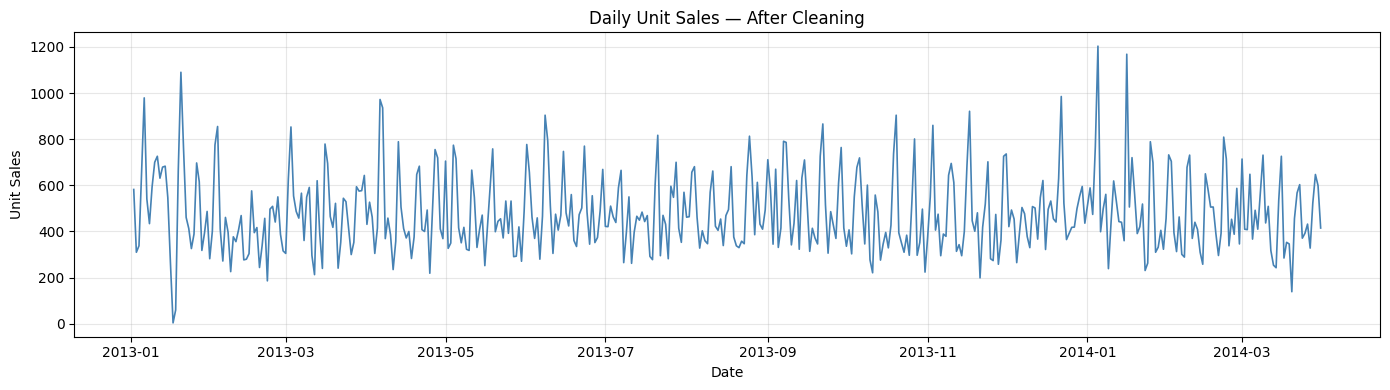

In [7]:
# ── Quick visual check ───────────────────────────────────────
# Plot unit_sales so we can visually confirm the data looks smooth and complete

plt.figure(figsize=(14, 4))
plt.plot(df.index, df['unit_sales'], color='steelblue', linewidth=1.2)
plt.title('Daily Unit Sales — After Cleaning')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 4 — Train / Test Split

We split the data by time, not randomly.  
The model always trains on the **past** and is tested on the **future**.

- **Training set:** January 2013 – December 2013  
- **Test set:** January 2014 – March 2014

In [8]:
# Split date — the boundary between training and testing
SPLIT_DATE = '2014-01-01'

df_train = df.loc[df.index < SPLIT_DATE].copy()
df_test  = df.loc[df.index >= SPLIT_DATE].copy()

print("Training rows:", len(df_train),
      " |", df_train.index.min().date(), "to", df_train.index.max().date())
print("Test rows:    ", len(df_test),
      " |", df_test.index.min().date(), "to", df_test.index.max().date())

Training rows: 364  | 2013-01-02 to 2013-12-31
Test rows:     90  | 2014-01-01 to 2014-03-31


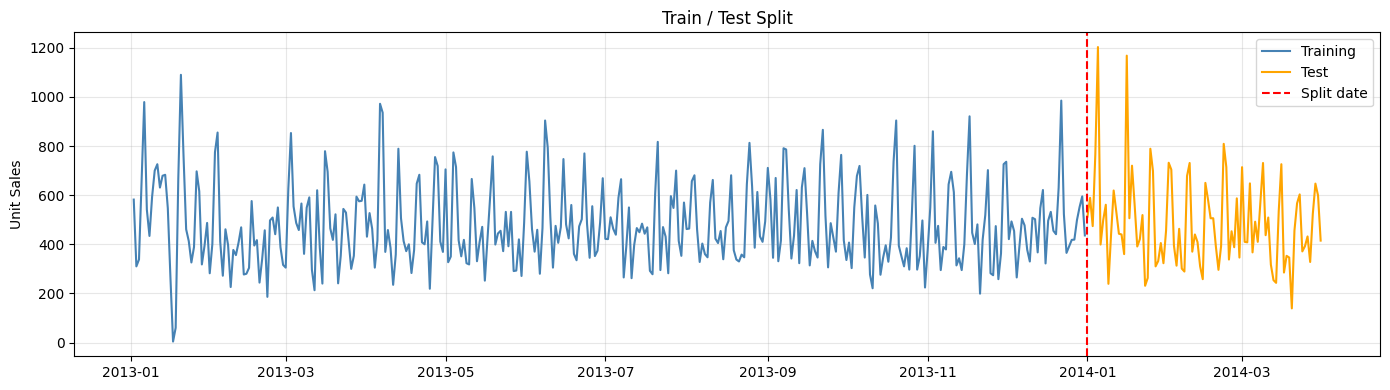

In [9]:
# Visualise the split
plt.figure(figsize=(14, 4))
plt.plot(df_train.index, df_train['unit_sales'], label='Training', color='steelblue')
plt.plot(df_test.index,  df_test['unit_sales'],  label='Test',     color='orange')
plt.axvline(pd.to_datetime(SPLIT_DATE), color='red', linestyle='--', label='Split date')
plt.title('Train / Test Split')
plt.ylabel('Unit Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 5 — Evaluation Metrics

We define **one reusable function** that calculates all metrics.  
Every model uses the same function — this keeps comparisons fair.

---

### The full metric toolkit

| Metric | Formula idea | What it tells you | Target |
|---|---|---|---|
| **MAE** | Average of \|actual − predicted\| | Typical error in same units as your data | As low as possible |
| **RMSE** | √(average of squared errors) | Same as MAE but large errors count more | As low as possible |
| **MAPE** | Average of \|error / actual\| × 100 | Error as a % — easy to explain to non-technical audiences | < 20% strong, 20–35% acceptable |
| **Bias** | Average of (predicted − actual) | Are we always too high or too low? | As close to 0 as possible |
| **R²** | 1 − (error variance / total variance) | How much variation does the model explain? | Closer to 1.0 is better |
| **Training time** | Clock time to fit the model | Fast enough for real-world retraining? | Practical constraint |

---

### Which metric to use for which model?

| Model | Primary metric | Why |
|---|---|---|
| **ARIMA / SARIMAX** | MAE + Bias | Errors should be symmetric — Bias catches directional drift |
| **Holt-Winters** | MAE + Bias | HW can lag trend changes — Bias flags this early |
| **Prophet** | MAPE + R² | Prophet is business-facing — % errors communicate well |
| **XGBoost** | RMSE | Optimised for squared error — RMSE matches what it was tuned on |
| **LSTM** | RMSE | Same as XGBoost — both are gradient-based learners |

In [10]:
def evaluate_model(name, actual, predicted, training_time=None):
    """
    Calculates and prints all evaluation metrics for one model.
    Returns a dictionary so results can be stored and compared.

    Parameters:
        name          : model name (string)
        actual        : true values (array)
        predicted     : predicted values (array)
        training_time : seconds the model took to train (float, optional)
    """
    import numpy as np
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    from sklearn.metrics import mean_absolute_percentage_error, r2_score

    actual    = np.array(actual)
    predicted = np.array(predicted)

    mae   = mean_absolute_error(actual, predicted)
    rmse  = np.sqrt(mean_squared_error(actual, predicted))
    bias  = np.mean(predicted - actual)
    r2    = r2_score(actual, predicted)

    # MAPE: skip zeros to avoid division by zero
    mask  = actual != 0
    mape  = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

    print(f"── {name} {'─' * max(1, 40 - len(name))}")
    print(f"  MAE:           {mae:.2f}  (avg error in sales units)")
    print(f"  RMSE:          {rmse:.2f}  (large errors weighted more)")
    print(f"  MAPE:          {mape:.1f}%  (error as % of actual — skip if zeros exist)")
    print(f"  Bias:          {bias:+.2f}  ({'over-predicting' if bias > 0 else 'under-predicting'})")
    print(f"  R²:            {r2:.3f}  (closer to 1.0 is better | < 0 worse than avg)")
    if training_time is not None:
        t = f"{training_time:.1f}s" if training_time < 60 else f"{training_time/60:.1f}m"
        print(f"  Training time: {t}")
    print()

    return {
        'model': name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE': round(mape, 1),
        'Bias': round(bias, 2),
        'R2': round(r2, 3),
        'Training_time_s': round(training_time, 1) if training_time else None
    }

# We will collect results from every model in this list

In [11]:
# This list collects one result dictionary per model.
# Every evaluate_model() call returns a dictionary — we append it here.
# At the end we convert this list into a comparison table with pd.DataFrame(results).

results = []

print("results list ready — will collect metrics from each model.")

results list ready — will collect metrics from each model.


---
## Step 6 — Define Features for ML Models

ARIMA and Holt-Winters use only the `unit_sales` column.  
XGBoost (and later LSTM) need **feature columns** as inputs.  
We define them once here and reuse them for every ML model.

In [12]:
# These are the same feature columns created in the Feature Engineering notebook
# Me: We have to define all these features but wwe do not have to use them all.



FEATURES = [
    'year', 'month', 'day', 'dayofweek', 'quarter', 'week_of_year',
    'is_weekend', 'is_month_start', 'is_month_end',
    'lag_1', 'lag_7', 'lag_14', 'lag_30',
    'rolling_7d_mean', 'rolling_14d_mean', 'rolling_30d_mean', 'rolling_7d_std',
    'dcoilwtico', 'oil_lag_1', 'oil_rolling_7d_mean',
    'is_national_holiday', 'is_regional_holiday', 'is_local_holiday',
]

TARGET = 'unit_sales'

# Set up train/test X and y for ML models
X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test  = df_test[FEATURES]
y_test  = df_test[TARGET]

print("Feature columns:", len(FEATURES))
print("Training samples:", len(X_train))
print("Test samples:    ", len(X_test))

Feature columns: 23
Training samples: 364
Test samples:     90


---
## Step 7 — Train All Models

We train five models on the same data.  
Each model follows the same pattern:
1. Fit on the training set  
2. Predict on the test set  
3. Evaluate with `evaluate_model()`

---
### Model 1 — ARIMA / SARIMAX

ARIMA is a classical statistical model for time series.  
We use SARIMAX here, which is ARIMA with seasonal terms and optional external variables.

In [13]:
# ── ARIMA / SARIMAX ──────────────────────────────────────────

# Use only the unit_sales series — ARIMA does not need other features
train_sales = df_train['unit_sales']
test_sales  = df_test['unit_sales']

# Fit a SARIMA model
# Order (1,1,1): one AR term, one difference, one MA term
# Seasonal order (1,1,1,7): same pattern repeated weekly (period=7 for daily data)
arima_model = SARIMAX(train_sales, order=(1,1,1), seasonal_order=(1,1,1,7))
arima_fit   = arima_model.fit(disp=False)   # disp=False silences training output

# Predict on the test period
arima_preds = arima_fit.forecast(steps=len(test_sales))

# Evaluate
arima_result = evaluate_model("ARIMA", test_sales.values, arima_preds.values)
results.append(arima_result)

── ARIMA ───────────────────────────────────
  MAE:           95.65  (avg error in sales units)
  RMSE:          143.68  (large errors weighted more)
  MAPE:          21.2%  (error as % of actual — skip if zeros exist)
  Bias:          -9.29  (under-predicting)
  R²:            0.386  (closer to 1.0 is better | < 0 worse than avg)



---
### Model 2 — Holt-Winters (Exponential Smoothing)

Holt-Winters extends simple exponential smoothing to handle **trend and seasonality**.  
It works well for data with a clear seasonal pattern, like weekly retail sales.

In [14]:
# ── Holt-Winters ─────────────────────────────────────────────

hw_model = ExponentialSmoothing(
    train_sales,
    trend='add',           # additive trend  (use 'mul' for multiplicative)
    seasonal='add',        # additive seasonality
    seasonal_periods=7     # weekly seasonality
)
hw_fit   = hw_model.fit()
hw_preds = hw_fit.forecast(len(test_sales))

hw_result = evaluate_model("Holt-Winters", test_sales.values, hw_preds.values)
results.append(hw_result)

── Holt-Winters ────────────────────────────
  MAE:           94.83  (avg error in sales units)
  RMSE:          143.07  (large errors weighted more)
  MAPE:          21.0%  (error as % of actual — skip if zeros exist)
  Bias:          -9.12  (under-predicting)
  R²:            0.392  (closer to 1.0 is better | < 0 worse than avg)



---
### Model 3 — Prophet

Prophet was built by Meta for business forecasting.  
It handles trend changes, seasonality, and holidays automatically.

In [15]:
# ── Prophet ──────────────────────────────────────────────────

# Prophet requires columns named exactly 'ds' (date) and 'y' (target)
prophet_train = df_train[['unit_sales']].reset_index()
prophet_train.columns = ['ds', 'y']

prophet_test = df_test[['unit_sales']].reset_index()
prophet_test.columns = ['ds', 'y']

# Fit the model
prophet_model = Prophet(weekly_seasonality=True, yearly_seasonality=True)
prophet_model.fit(prophet_train)

# Create a future dataframe for the test period and predict
future       = prophet_model.make_future_dataframe(periods=len(prophet_test), freq='D')
prophet_fore = prophet_model.predict(future)

# Extract only the test period predictions
prophet_preds = prophet_fore.set_index('ds')['yhat'].loc[prophet_test['ds']]

prophet_result = evaluate_model("Prophet", prophet_test['y'].values, prophet_preds.values)
results.append(prophet_result)

16:58:31 - cmdstanpy - INFO - Chain [1] start processing
16:58:31 - cmdstanpy - INFO - Chain [1] done processing


── Prophet ─────────────────────────────────
  MAE:           156.53  (avg error in sales units)
  RMSE:          201.94  (large errors weighted more)
  MAPE:          30.9%  (error as % of actual — skip if zeros exist)
  Bias:          -144.59  (under-predicting)
  R²:            -0.212  (closer to 1.0 is better | < 0 worse than avg)



---
### Model 4 — XGBoost

XGBoost is a machine learning model that uses decision trees.  
It does not understand time on its own — but our feature engineering  
(lag values, rolling averages, calendar flags) gives it that information.

In [16]:
# ── XGBoost — baseline ───────────────────────────────────────

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
xgb_preds = xgb_model.predict(X_test)

xgb_result = evaluate_model("XGBoost (baseline)", y_test.values, xgb_preds)
results.append(xgb_result)

── XGBoost (baseline) ──────────────────────
  MAE:           108.60  (avg error in sales units)
  RMSE:          155.72  (large errors weighted more)
  MAPE:          24.8%  (error as % of actual — skip if zeros exist)
  Bias:          +5.53  (over-predicting)
  R²:            0.279  (closer to 1.0 is better | < 0 worse than avg)



---
### Model 5 — LSTM (Optional / Advanced)

> **Note for instructors:** This cell is marked optional.  
> LSTM training takes 5–15 minutes depending on the machine.  
> You can pre-run this cell and show the output, or skip it and  
> focus on XGBoost for the hyperparameter tuning section.

LSTM is a type of neural network that can learn patterns across sequences of time steps.  
It is the most powerful model in this pipeline — but also the most complex to train.

In [17]:
# ── LSTM (OPTIONAL: It takes time to run this model) ──────────────────

from sklearn.preprocessing import MinMaxScaler
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

LOOK_BACK = 7   # Use the past 7 days to predict the next day

# Scale unit_sales to [0, 1] — helps the network learn faster
scaler = MinMaxScaler()
sales_scaled = scaler.fit_transform(df[['unit_sales']]).flatten()

# Build sliding-window sequences
def create_sequences(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i : i + look_back])
        y.append(data[i + look_back])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(sales_scaled, LOOK_BACK)

# Train/test split on sequences
split_idx = len(df_train) - LOOK_BACK
X_tr, y_tr = X_seq[:split_idx], y_seq[:split_idx]
X_te, y_te = X_seq[split_idx:], y_seq[split_idx:]

# Convert to PyTorch tensors
X_tr_t = torch.FloatTensor(X_tr).unsqueeze(-1)
y_tr_t = torch.FloatTensor(y_tr).unsqueeze(-1)
X_te_t = torch.FloatTensor(X_te).unsqueeze(-1)

# Define a simple LSTM model
class SimpleLSTM(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.lstm   = nn.LSTM(1, hidden, batch_first=True)
        self.linear = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.linear(out[:, -1, :])

lstm_model = SimpleLSTM(hidden=64)
optimizer  = torch.optim.Adam(lstm_model.parameters(), lr=0.001)
loss_fn    = nn.MSELoss()

# Train for 30 epochs
for epoch in range(30):
    lstm_model.train()
    optimizer.zero_grad()
    preds = lstm_model(X_tr_t)
    loss  = loss_fn(preds, y_tr_t)
    loss.backward()
    optimizer.step()

# Predict and inverse-scale
lstm_model.eval()
with torch.no_grad():
    lstm_raw   = lstm_model(X_te_t).numpy().flatten()
lstm_preds_inv = scaler.inverse_transform(lstm_raw.reshape(-1,1)).flatten()

lstm_result = evaluate_model("LSTM", y_test.values[-len(lstm_preds_inv):], lstm_preds_inv)
results.append(lstm_result)

print("LSTM cell is commented out. Uncomment to run.")

── LSTM ────────────────────────────────────
  MAE:           174.05  (avg error in sales units)
  RMSE:          207.29  (large errors weighted more)
  MAPE:          46.1%  (error as % of actual — skip if zeros exist)
  Bias:          +94.79  (over-predicting)
  R²:            -0.277  (closer to 1.0 is better | < 0 worse than avg)

LSTM cell is commented out. Uncomment to run.


---
## Step 8 — Compare All Models

Now we collect all results into one table so we can pick the best model.

In [18]:
# Build a comparison table from all results collected above
df_results = pd.DataFrame(results).set_index('model')

print("Model Comparison Table")
print("=" * 55)
print(df_results.round(2).to_string())
print()
print("Best model by MAE: ", df_results['MAE'].idxmin())
print("Best model by RMSE:", df_results['RMSE'].idxmin())

Model Comparison Table
                       MAE    RMSE  MAPE    Bias    R2 Training_time_s
model                                                                 
ARIMA                95.65  143.68  21.2   -9.29  0.39            None
Holt-Winters         94.83  143.07  21.0   -9.12  0.39            None
Prophet             156.53  201.94  30.9 -144.59 -0.21            None
XGBoost (baseline)  108.60  155.72  24.8    5.53  0.28            None
LSTM                174.05  207.29  46.1   94.79 -0.28            None

Best model by MAE:  Holt-Winters
Best model by RMSE: Holt-Winters


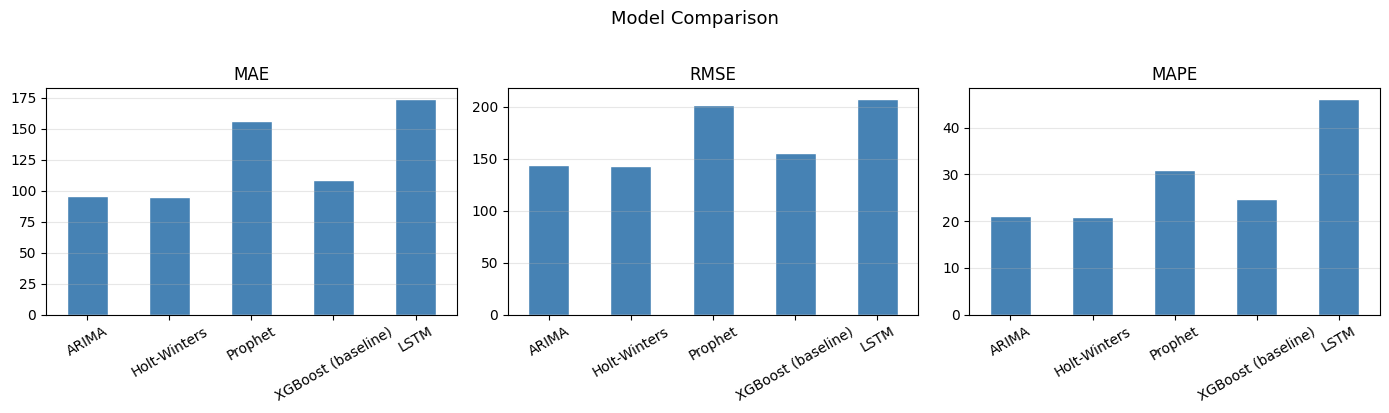

In [19]:
# Visualise the comparison as a bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    df_results[metric].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Model Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 9 — Hyperparameter Tuning (XGBoost)

A **hyperparameter** is a setting you choose before training begins.  
Examples: how many trees to build, how deep each tree can grow.

**Hyperparameter tuning** searches through combinations of these settings  
to find the ones that produce the lowest error.

We use two tools:
- `TimeSeriesSplit` — splits time series data correctly for cross-validation  
  (always trains on the past, validates on the future — never the other way around)
- `RandomizedSearchCV` — randomly samples combinations from a grid and finds the best

> **Why not try every combination?**  
> If we have 5 settings each with 5 values, that is 5⁵ = 3,125 combinations.  
> Randomized search picks a sample (e.g. 20) and finds a good-enough answer quickly.

In [20]:
# ── Define the search grid ───────────────────────────────────
# Each key is a hyperparameter.
# Each value is a list of options to try.

param_grid = {
    'n_estimators':  [100, 300, 500], # Decision trees, each one learning from the mistakes of the previous one
    'max_depth':     [3, 4, 5, 6], # How many splits each tree can make (more depth = more complex)
    'learning_rate': [0.01, 0.05, 0.1], # How much each tree contributes to the final prediction (lower = more trees needed)
    'subsample':     [0.7, 0.8, 1.0], # What fraction of the training data each tree sees (lower = more randomness)
}

# TimeSeriesSplit: 3 folds, always training on the past, validating on the future
tscv = TimeSeriesSplit(n_splits=3)

# Set up the search — try 20 random combinations
search = RandomizedSearchCV(
    estimator  = xgb.XGBRegressor(verbosity=0, random_state=42),
    param_distributions = param_grid,
    n_iter     = 20,          # Number of random combinations to try
    scoring    = 'neg_mean_absolute_error',
    cv         = tscv,
    random_state = 42,
    n_jobs     = -1           # Use all available CPU cores
)

print("Starting hyperparameter search — this may take 1–2 minutes...")
search.fit(X_train, y_train)

print()
print("Best parameters found:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")

Starting hyperparameter search — this may take 1–2 minutes...

Best parameters found:
  subsample: 0.8
  n_estimators: 300
  max_depth: 3
  learning_rate: 0.01


In [21]:
# ── Evaluate the tuned model ─────────────────────────────────

best_xgb   = search.best_estimator_
tuned_preds = best_xgb.predict(X_test)

tuned_result = evaluate_model("XGBoost (tuned)", y_test.values, tuned_preds)
results.append(tuned_result)

# Compare baseline vs tuned
print("Improvement over baseline:")
baseline_mae = df_results.loc['XGBoost (baseline)', 'MAE']
print(f"  Baseline MAE: {baseline_mae:.2f}")
print(f"  Tuned MAE:    {tuned_result['MAE']:.2f}")
print(f"  Reduction:    {baseline_mae - tuned_result['MAE']:.2f} units")

── XGBoost (tuned) ─────────────────────────
  MAE:           96.30  (avg error in sales units)
  RMSE:          141.45  (large errors weighted more)
  MAPE:          22.0%  (error as % of actual — skip if zeros exist)
  Bias:          -2.19  (under-predicting)
  R²:            0.405  (closer to 1.0 is better | < 0 worse than avg)

Improvement over baseline:
  Baseline MAE: 108.60
  Tuned MAE:    96.30
  Reduction:    12.30 units


---
## Step 10 — Track Experiments with MLflow

**What is MLflow?**  
MLflow is a tool that records every model training run — the settings you used,  
the results you got, and any files produced. It answers the question:  
*"Which model with which settings gave me the best result?"*

**Why does this matter in practice?**  
Without MLflow, teams lose track of what they tried. With MLflow, every  
experiment is saved automatically and you can compare them visually in a browser.

**Three things we log for each run:**
- **Parameters** — the settings we chose (e.g. `max_depth=4`)
- **Metrics** — the results we measured (e.g. `MAE=82.3`)
- **Model** — the trained model file itself

---
### MLflow setup

In [ ]:
#Me: did not worked for him. ask him to fix it and get the final one


import os
import mlflow

# Define your project folder — change this to your actual path
DATA_DIR = r"C:\\Users\\alipa\\Documents\\3- Academic\\6- Data Science, phyton\\1- class files\\9- Time Series Modeling\\Time-Series"

# Build the MLflow path and add the required file:/// prefix
MLFLOW_PATH = os.path.join(DATA_DIR, "mlruns")
mlflow.set_tracking_uri("file:///" + MLFLOW_PATH.replace("\\", "/"))

# Create (or select) an experiment
mlflow.set_experiment("retail_sales_forecasting")

print("MLflow tracking folder:", MLFLOW_PATH)
print("Experiment set: retail_sales_forecasting")

MLflow tracking folder: C:\\Users\\alipa\\Documents\\3- Academic\\6- Data Science, phyton\\1- class files\\9- Time Series Modeling\\Time-Series\mlruns
Experiment set: retail_sales_forecasting


---
### Log all model results to MLflow

We log every model we trained today in one loop.  
Each model becomes a separate **run** inside the experiment.

In [23]:
# ── Build the full results table including the tuned model ───
all_results = pd.DataFrame(results)
print("Logging", len(all_results), "runs to MLflow...")
print()

Logging 6 runs to MLflow...



In [24]:
# ── Log each model as one MLflow run ─────────────────────────

for _, row in all_results.iterrows():
    with mlflow.start_run(run_name=row['model']):

        # Log the metrics we calculated
        mlflow.log_metric("MAE",  row['MAE'])
        mlflow.log_metric("RMSE", row['RMSE'])
        mlflow.log_metric("MAPE", row['MAPE'])
        mlflow.log_metric("Bias", row['Bias'])
        mlflow.log_metric("R2",   row['R2'])

        # Log the model name as a parameter
        mlflow.log_param("model_type", row['model'])

        print(f"  Logged: {row['model']}  |  MAE={row['MAE']:.2f}  RMSE={row['RMSE']:.2f}  R2={row['R2']:.2f}")

print()
print("All runs logged!")

  Logged: ARIMA  |  MAE=95.65  RMSE=143.68  R2=0.39
  Logged: Holt-Winters  |  MAE=94.83  RMSE=143.07  R2=0.39
  Logged: Prophet  |  MAE=156.53  RMSE=201.94  R2=-0.21
  Logged: XGBoost (baseline)  |  MAE=108.60  RMSE=155.72  R2=0.28
  Logged: LSTM  |  MAE=174.05  RMSE=207.29  R2=-0.28
  Logged: XGBoost (tuned)  |  MAE=96.30  RMSE=141.45  R2=0.41

All runs logged!


In [25]:
# Pick the best model based on MAE — lowest MAE wins
best_model_name = df_results['MAE'].idxmin()    # You can change this to 'RMSE' or any other metric if you prefer

print(f"Best model: {best_model_name}")
print(f"MAE:  {df_results.loc[best_model_name, 'MAE']}")
print(f"RMSE: {df_results.loc[best_model_name, 'RMSE']}")
print(f"MAPE: {df_results.loc[best_model_name, 'MAPE']}%")
print(f"Bias: {df_results.loc[best_model_name, 'Bias']:+.2f}"   )
print(f"R2:   {df_results.loc[best_model_name, 'R2']}")

Best model: Holt-Winters
MAE:  94.83
RMSE: 143.07
MAPE: 21.0%
Bias: -9.12
R2:   0.392


---
## Summary — What We Built Today

| Step | What we did |
|---|---|
| Data cleaning | Detected and filled missing dates and values |
| 5 models trained | ARIMA, Holt-Winters, Prophet, XGBoost, (LSTM optional) |
| Consistent evaluation | Same metrics for every model — fair comparison |
| Hyperparameter tuning | Found better XGBoost settings with RandomizedSearchCV |
| MLflow tracking | Every run saved |

- Start building the Streamlit forecasting app

---
> **GitHub commit for today:**  
> Add `W3-mlflow.ipynb` to your repo and commit with a message